In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Remember to switch the runtime into the GPU mode for the faster computation in CNN.

In [2]:
# import the common libraries to be used
import numpy as np
import pandas as pd

In [3]:
# used to unzip the dataset in google drive
#!unzip '/content/drive/MyDrive/side project 3/Animals From Kaggle.zip' -d '/content/drive/MyDrive/side project 3/unzipped animals'

In [4]:
"""# import the libraries which are necessary for managing the dataset

# import the os library which performs operating system task
# the like the files and directories management
import os
# import the Python imaging library
# opening, manipulating, and saving various image file formats
from PIL import Image
# import the Dataset and Dataloader
# the Dataset defien the way to manipulate the dataset
# which gives __len__, __getitem__
# the Dataloader performs the shuffling and the batch for the dataset
from torch.utils.data import Dataset, DataLoader

# create a class for hadling the photos dataset

class Custom_Image_Dataset(Dataset):
    # define the constructor to define the variables
    # it receives the root directory where the images are stored
    # like the path to the directory, path/location of the folder
    # it also receives the transform
    # it determines how does the dataset transform in a specific way
    # e.g. changing size
    def __init__(self, root_dir, transform = None):
        # define the variables
        # the path
        self.root_dir = root_dir
        # the transformation on the photos
        self.transform = transform
        # create the empty lists to store the images and labels respectively
        self.images = []
        self.labels = []

        # Begin to loop through the directories to search for the photos
        # then assign the labels for them according to their location and names of the folders stored
        # then append the list

        # 1. retrieves a list of all files and directories in the specified root_dir
        # 2. combine the labels with path(specific photo) according to the folder name
        # 3. append the lists of labels and images(store the path of the photos)

        # loop through the path to search for all files or folders according to the path where all the dataset is stored
        # in this case, the os.lisdir(root_dir) returns the list of ['cat', 'non-cat']
        # the codes below depends on the structure of the organisation of directory
        for label in os.listdir(root_dir):
            # construct the full path to the current entry (label) by combining the root_dir with the label
            # meaning that it chase to the further file inside that folder
            # os.join.path(root_dir, label) go through the path of /path_to_your_dataset/cat and assign it into a new variable
            # path_to_your_dataset -> cat
            label_dir = os.path.join(root_dir, label)
            # if the name of the folder is cat, assign the label of the phots as 0
            # make sure the name of the label is correct
            if label == 'cat':
                # similarly, we will chase the content inside the /path_to_your_dataset/cat
                # take the content indside and return as  the list
                # e.g. os.listdir(label_dir) returns ['cat1.jpg', 'cat2.png', 'cat3.jpeg']
                for img_name in os.listdir(label_dir):
                    # similarly, we will go through the image(path) to take the content
                    # os.join.path(label_dir, img_name) creates /path_to_your_dataset/cats/cat1.jpg.
                    img_path = os.path.join(label_dir, img_name)
                    # check the files if they matching requirement of the format
                    # as this is CNN, we want the format in '.png', '.jpg', '.jpeg'
                    if img_path.endswith(('.png', '.jpg', '.jpeg')):
                        # if the format is correct, append the path into the list
                        # also, append 0 for the 'cat' as the label
                        self.images.append(img_path)
                        self.labels.append(0)

            # for the folder which is not 'cat'
            # the remaining folder is 'non-cat'
            elif label == 'non-cat':
                # check the images directly inside the folder (if any)
                for img_name in os.listdir(label_dir):
                    img_path = os.path.join(label_dir, img_name)
                    if img_path.endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(img_path)
                        self.labels.append(1)

                # now check for subdirectories within the 'non-cat' folder
                for sub_label in os.listdir(label_dir):
                    sub_label_dir = os.path.join(label_dir, sub_label)
                    # Check if it's a folder
                    if os.path.isdir(sub_label_dir):
                        for img_name in os.listdir(sub_label_dir):
                            img_path = os.path.join(sub_label_dir, img_name)
                            if img_path.endswith(('.png', '.jpg', '.jpeg')):
                                self.images.append(img_path)
                                self.labels.append(1)

    # end of constructor

    # this function in the class return the length of the dataset
    # this is used to split the dataset into the training set and the testing set
    # this is also a requirement for the Pytorch in batching
    def __len__(self):
        return len(self.images)
        # len(self.images) should be same as len(self.labels)

    # retrieving a specific item (image and its corresponding label) from the dataset based on an index
    # for iteration and batching in data loaders
    def __getitem__(self, idx):
        # access the image according to their index location of the list
        img_path = self.images[idx]
        # open and convert the image to RGB format
        image = Image.open(img_path).convert('RGB')
        # access the labels according to their index location of the list
        # ensures that each image is paired with its correct label.
        label = self.labels[idx]

        # if there is any transformation
        # apply it to the image(after converting to RGB, with 3 channels)
        if self.transform:
            image = self.transform(image)

        return image, label

# end of the class of manipulating the dataset
# assign the labels to the photos
# count the number of dataset
# access the image and perform transformation"""

"# import the libraries which are necessary for managing the dataset\n\n# import the os library which performs operating system task\n# the like the files and directories management\nimport os\n# import the Python imaging library\n# opening, manipulating, and saving various image file formats\nfrom PIL import Image\n# import the Dataset and Dataloader\n# the Dataset defien the way to manipulate the dataset\n# which gives __len__, __getitem__\n# the Dataloader performs the shuffling and the batch for the dataset\nfrom torch.utils.data import Dataset, DataLoader\n\n# create a class for hadling the photos dataset\n\nclass Custom_Image_Dataset(Dataset):\n    # define the constructor to define the variables\n    # it receives the root directory where the images are stored\n    # like the path to the directory, path/location of the folder\n    # it also receives the transform\n    # it determines how does the dataset transform in a specific way\n    # e.g. changing size\n    def __init__(sel

In [5]:
# enhanced version with less for loop
# using less computational time in training loop
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class Custom_Image_Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # define paths for categories
        self.cat_path = os.path.join(root_dir, 'cat')
        self.non_cat_path = os.path.join(root_dir, 'non-cat')

        # load images and labels using list comprehensions
        self.cat_images = [os.path.join(self.cat_path, img) for img in os.listdir(self.cat_path)
                          if img.endswith(('.png', '.jpg', '.jpeg'))]
        self.non_cat_images = [os.path.join(self.non_cat_path, img) for img in os.listdir(self.non_cat_path)
                               if img.endswith(('.png', '.jpg', '.jpeg'))]

        # include images from subdirectories within 'non-cat'
        for sub_label in os.listdir(self.non_cat_path):
            sub_label_dir = os.path.join(self.non_cat_path, sub_label)
            if os.path.isdir(sub_label_dir):
                self.non_cat_images += [os.path.join(sub_label_dir, img) for img in os.listdir(sub_label_dir)
                                        if img.endswith(('.png', '.jpg', '.jpeg'))]

        # combine all images
        self.all_images = self.cat_images + self.non_cat_images

        # labels: 0 for 'cat', 1 for 'non-cat'
        self.labels = [0] * len(self.cat_images) + [1] * len(self.non_cat_images)

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, idx):
        img_path = self.all_images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
# now, define the transformation
from torchvision import transforms

Transformation = transforms.Compose([
    # this resizes all the images to make them uniform
    # resize it to a suitable value such that the parameter will be not too large
    # turning into a long computational time
    transforms.Resize((32,32)),
    # convert the images to tensor
    # convert from 2D array to 3D tensor
    # then later we can use CNN to performs various operation
    transforms.ToTensor(),
    # perform normalization for each channel, R,G,B
    # normalizes a tensor image with mean and standard deviation for each channel
    # sd = 0.5 for each RGB, mean = 0.5 for each RGB, then the range is [-1, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

In [7]:
# Create the dataset!!! or create the object of the dataset by using the class
root_dir = '/content/drive/MyDrive/side project 3/unzipped animals/Animals From Kaggle'
# pass the path of the dataset and the transformation to the class and create the object name dataset
dataset = Custom_Image_Dataset(root_dir = root_dir, transform = Transformation)

In [8]:
# check if the directory exists or not
if not os.path.exists(root_dir) or not os.path.isdir(root_dir):
    raise ValueError(f"The specified root directory does not exist: {root_dir}")

In [9]:
# print the total number of the dataset to check if loaded correctly or not
# half of the dataset is 'cat', remaining half is 'non-cat'
print(len(dataset))

10680


In [10]:
# 1) split the training set, validation set and testing set mannually
import torch
# define the size of each set mannually

# training size as 75% of the whole dataset
train_size = int(0.75* len(dataset))
# validate size as 15% of the whole dataset
# this is used to salect the best model with the least loss during the validation state after training
valid_size = int(0.15* len(dataset))
# the rest of the dataset is used for the testing
test_size = len(dataset) - train_size - valid_size

# ensure the reproductility
torch.manual_seed(0)

In [11]:
# 2) create the dataloader for the training set and the testing set

# split the data
from torch.utils.data import random_split

train_set, valid_set, test_set = random_split(dataset, [train_size,valid_size,test_size])
# set the batch size
Batch_size = 32

# create DataLoaders and give the batch size and set the shuffling
# insert the object of the dataset created by class to the dataloader
train_loader = DataLoader(train_set, batch_size = Batch_size, shuffle = True)
valid_loader = DataLoader(valid_set, batch_size = Batch_size, shuffle = False)
test_loader = DataLoader(test_set, batch_size = Batch_size, shuffle = False)

In [12]:
# now, define the struture of the CNN model

import torch
import torch.nn as nn

class CNN_Model(nn.Module):
    # define the constructor
    # define variables
    def __init__(self):
        # rememeber to add the class name inside the bracket
        super(CNN_Model, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 8, kernel_size= (5,5))
        # (32 - 5 + 0)/1 + 1 = 28
        self.relu = nn.ReLU()
        self.pool_1 = nn.MaxPool2d(kernel_size = 2)
        # (28 - 2 + 0)/2 + 1 = 14
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 24, kernel_size = (3,3))
        # (14 - 3 + 0)/1 + 1 = 12

        self.relu = nn.ReLU()
        self.pool_2 = nn.MaxPool2d(kernel_size = 2)
        # (12 - 2 + 0)/2 + 1 = 6

        # add the flattening layer which convert 3D to 1D array
        self.flatten = nn.Flatten()

        # fully connected layer
        self.fc1 = nn.Linear(24*6*6, 64)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(64, 32)
        # ouptut layer must 2, as there are only 2 classes to be distinguished (cat, non-cat)
        self.fc3 = nn.Linear(32, 2)
        self.softmax = nn.Softmax(dim=1)

        # make sure the numbers of nodes of each layers are matching
        # otherwise, it cannot give the output


    # define the forward function now
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool_1(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool_2(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.dropout(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.dropout(x)
        x = self.relu(x)

        x = self.fc3(x)

        x = self.softmax(x)
        return x


In [13]:
# now, define the struture of the CNN model

import torch
import torch.nn as nn

class CNN_Model(nn.Module):
    # define the constructor
    # define variables
    def __init__(self):
        # rememeber to add the class name inside the bracket
        super(CNN_Model, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 8, kernel_size= (5,5))
        # (32 - 5 + 0)/1 + 1 = 28
        self.relu = nn.ReLU()
        self.pool_1 = nn.MaxPool2d(kernel_size = 2)
        # (28 - 2 + 0)/2 + 1 = 14
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 24, kernel_size = (3,3))
        # (14 - 3 + 0)/1 + 1 = 12

        self.relu = nn.ReLU()
        self.pool_2 = nn.MaxPool2d(kernel_size = 2)
        # (12 - 2 + 0)/2 + 1 = 6

        # add the flattening layer which convert 3D to 1D array
        self.flatten = nn.Flatten()

        # fully connected layer
        self.fc1 = nn.Linear(24*6*6, 64)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(64, 32)
        # ouptut layer must 2, as there are only 2 classes to be distinguished (cat, non-cat)
        self.fc3 = nn.Linear(32, 2)
        self.softmax = nn.Softmax(dim=1)

        # make sure the numbers of nodes of each layers are matching
        # otherwise, it cannot give the output


    # define the forward function now
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool_1(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool_2(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.dropout(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.dropout(x)
        x = self.relu(x)

        x = self.fc3(x)

        x = self.softmax(x)
        return x


In [14]:
# initialize the model by using the class (define object)
Model_CNN = CNN_Model()

In [15]:
# print the summary of the CNN model
from torchsummary import summary
# set device, has to be done if switching to GPU mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# move the model to the appropriate device
Model_CNN.to(device)

# create a dummy input tensor with batch size of 32
dummy_input = torch.randn(32, 3, 32, 32).to(device)  # Batch size of 32

# print the model summary
summary(Model_CNN, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 28, 28]             608
              ReLU-2            [-1, 8, 28, 28]               0
         MaxPool2d-3            [-1, 8, 14, 14]               0
            Conv2d-4           [-1, 24, 12, 12]           1,752
              ReLU-5           [-1, 24, 12, 12]               0
         MaxPool2d-6             [-1, 24, 6, 6]               0
           Flatten-7                  [-1, 864]               0
            Linear-8                   [-1, 64]          55,360
           Dropout-9                   [-1, 64]               0
             ReLU-10                   [-1, 64]               0
           Linear-11                   [-1, 32]           2,080
          Dropout-12                   [-1, 32]               0
             ReLU-13                   [-1, 32]               0
           Linear-14                   

In [16]:
# define loss function, optimizer
import torch.optim as optim

# using cross entropy as the loss function from the torch library
loss_func = nn.CrossEntropyLoss()
# using Adam as the optimization method
# put the defined model into the fucntion and the "optimizer" as the name of the object
# modify the learning rate to seek for a faster training speed or the ease of convergence
optimizer = optim.Adam(Model_CNN.parameters(), lr = 0.001)

In [17]:
# training loop + validation
# combine everything together
# perform the forward and backward propagation

# define the number to train the whole dataset
epochs = 8
# set best_acc as 0 and later save the model with highest accuracy in the validation phase
best_acc = 0.0

for epoch in range(epochs):
    # set the model in training mode with better performance
    Model_CNN.train()
    # set the loss as 0
    run_loss = 0.0

    # make sure inputs is in front of the labels, (correct sequence)
    for inputs, labels in train_loader:
        # has to be done if switching to GPU mode
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the gradient first
        optimizer.zero_grad()
        # forward propagation
        outputs = Model_CNN(inputs)
        # compute the loss by the loss function
        loss = loss_func(outputs, labels)
        # backward propagation/pass
        loss.backward()
        # perform the gradient descent, optimize wieghts and biases
        optimizer.step()

        # get the loss statistic
        run_loss += loss.item()

    # print the epoch, average loss
    print(f'Epoch[{epoch + 1}/{epochs}], Training Loss: {run_loss/len(train_loader)}')
    # end of training

    # start the validation

    # set the model into validation mode
    Model_CNN.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    # used to track the predictions and labels during validation
    # to create the confusion matrix for better understanding the weakness or performanc eof the model
    all_predictions = []
    all_labels = []
    # require no gradient computation in the validation set
    # select the model with the highest accuracy in the validation set
    with torch.no_grad():
        # perform the simliar stuffs as the training
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = Model_CNN(inputs)

            loss = loss_func(outputs, labels)
            val_loss += loss.item()

            # calculate the accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Store predictions and true labels
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # print average validation loss and accuracy for the epoch
    print(f'Epoch {epoch+1}/{epochs} - Validation loss: {val_loss/len(valid_loader)}')
    print(f'Epoch {epoch+1}/{epochs} - Validation accuracy: {100 * correct / total}%')

    # save the model if the current accuracy is the best
    acc = 100 * correct / total
    if acc > best_acc:
        best_acc = acc
        torch.save(Model_CNN.state_dict(), 'best_model.pth')
        print(f'Model improved and saved with accuracy: {acc}%')

print('Finished Training')


Epoch[1/8], Training Loss: 0.6469804490229998
Epoch 1/8 - Validation loss: 0.6045490918206233
Epoch 1/8 - Validation accuracy: 67.54057428214732%
Model improved and saved with accuracy: 67.54057428214732%
Epoch[2/8], Training Loss: 0.6072135464366214
Epoch 2/8 - Validation loss: 0.5761193872666827
Epoch 2/8 - Validation accuracy: 72.03495630461923%
Model improved and saved with accuracy: 72.03495630461923%
Epoch[3/8], Training Loss: 0.5949256148233831
Epoch 3/8 - Validation loss: 0.5666444289918039
Epoch 3/8 - Validation accuracy: 73.78277153558052%
Model improved and saved with accuracy: 73.78277153558052%
Epoch[4/8], Training Loss: 0.5840387389479406
Epoch 4/8 - Validation loss: 0.5606260907416251
Epoch 4/8 - Validation accuracy: 73.65792759051186%
Epoch[5/8], Training Loss: 0.5736164089693017
Epoch 5/8 - Validation loss: 0.5543689645972907
Epoch 5/8 - Validation accuracy: 75.09363295880149%
Model improved and saved with accuracy: 75.09363295880149%
Epoch[6/8], Training Loss: 0.56299

<Figure size 800x600 with 0 Axes>

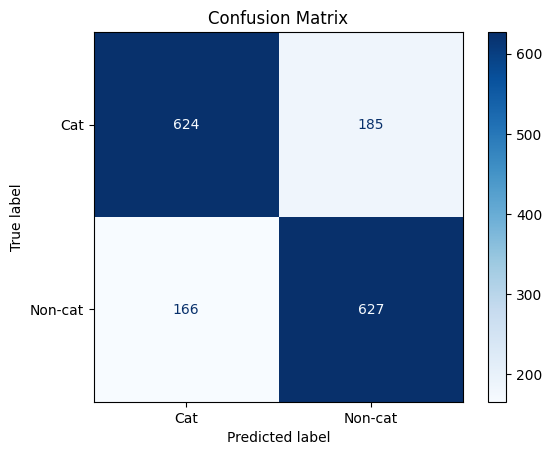

In [18]:
# plot the confusion matrix with importing the useful libraries
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# plot confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Non-cat'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [19]:
# check if the size of the dataloader is correct
print(inputs.shape)

torch.Size([2, 3, 32, 32])


In [20]:
# load the best model for the testing set

# assign with a new name of the object for the best model
model = CNN_Model()
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

<ipython-input-20-2080b21c615f>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


CNN_Model(
  (conv1): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1))
  (relu): ReLU()
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 24, kernel_size=(3, 3), stride=(1, 1))
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=864, out_features=64, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (softmax): Softmax(dim=1)
)

In [21]:
# likewise to the validation, using the similar structure to the testing part
test_loss = 0.0
test_total = 0
test_correct = 0
# using the lists to store the images, labels, predictions
# later can display some of the random images, their true labels and predictions respectively
all_test_images = []
all_test_labels = []
all_test_predictions = []

with torch.no_grad():
        # perform the simliar stuffs as the training
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)

            loss = loss_func(outputs, labels)
            test_loss += loss.item()

            # calculate the accuracy
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

            # store images, true labels, and predictions
            all_test_images.extend(inputs.cpu())
            all_test_labels.extend(labels.cpu().numpy())
            all_test_predictions.extend(predicted.cpu().numpy())

# print average validation loss and accuracy for the epoch
print(f'Testing loss: {test_loss/len(test_loader)}')
print(f'Testing accuracy: {100 * test_correct / test_total}%')

Testing loss: 0.5390568016206517
Testing accuracy: 75.74906367041199%


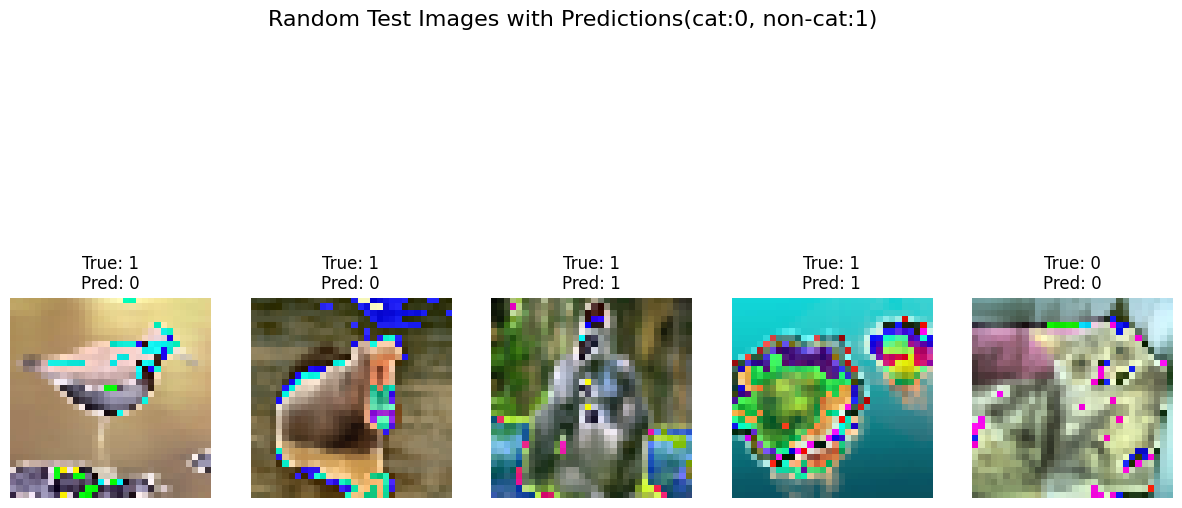

In [23]:
# randomly display 5 of the prediction results of the testing part

import random

random_indices = random.sample(range(len(all_test_images)), 5)

# set up the plot
plt.figure(figsize=(15, 8))

for i, idx in enumerate(random_indices):
    # convert the tensor image to a PIL image
    image = transforms.ToPILImage()(all_test_images[idx])
    label = all_test_labels[idx]
    prediction = all_test_predictions[idx]

    # display the image
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'True: {label}\nPred: {prediction}')

plt.suptitle('Random Test Images with Predictions(cat:0, non-cat:1)', fontsize=16)
plt.show()